## EStimation of minimum detection limit

Estimation of the minimum detection limit assuming power law distribution of plumes.

In [1]:
import os
import logging
from marss2l.utils import setup_stream_logger, pathjoin

from huggingface_hub import hf_file_system
from marss2l.huggingface import REPO_ID

fs = hf_file_system.HfFileSystem()

logger = logging.getLogger(__name__)
setup_stream_logger(logger, level=logging.DEBUG)

os.makedirs("figures", exist_ok=True)

/home/gonzalo/mambaforge/envs/marss2ltacopy312/lib/python3.12/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from marss2l import loaders
# Import the dataset
csv_path = f"datasets/{REPO_ID}/validated_images_all.csv" 
dataframe_data_traintest = loaders.read_csv(csv_path, 
                                            add_columns_for_analysis=True, 
                                            add_case_study=True,
                                            split="all",
                                            fs=fs)
dataframe_data_traintest.shape

(93538, 58)

In [3]:
dataframe_data_traintest.wind_speed

0        1.272366
1        9.473606
2        2.706137
3        2.847182
4        2.553369
           ...   
93533    2.597047
93534    3.972999
93535    2.986347
93536    7.540548
93537    4.672324
Name: wind_speed, Length: 93538, dtype: float64

In [4]:
# Take positives only
case_studies_exclude = ["Rest","Offshore","Venezuela"]

df_data = dataframe_data_traintest[(dataframe_data_traintest["ch4_fluxrate"] > 0) &\
                                   (dataframe_data_traintest['split_name']=='test_2023') &\
                                   (~dataframe_data_traintest.case_study.isin(case_studies_exclude))]
# Filter by country
# df_data = df_data[df_data['country']=='Algeria']
df_data.case_study.value_counts()

case_study
Turkmenistan                  852
Algeria                       300
United States of America      143
Libya                         127
Arabian peninsula             114
Syrian Arab Republic           99
Iran (Islamic Republic of)     70
Uzbekistan & Kazakhstan        43
Egypt                          24
Iraq                            7
Name: count, dtype: int64

## Plot histogram of flux rates

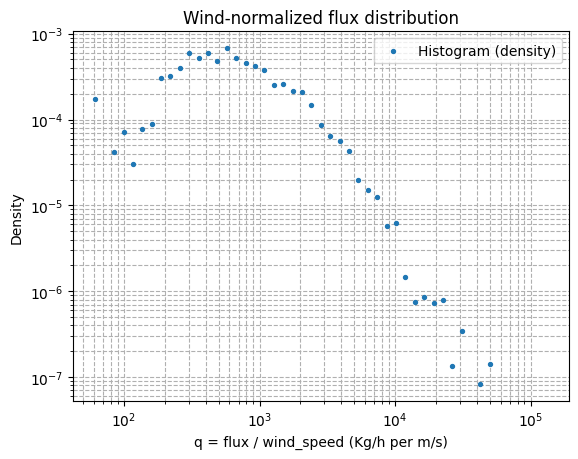

In [5]:
import numpy as np
import matplotlib.pylab as plt

flux = df_data["ch4_fluxrate"].to_numpy()
wind = df_data["wind_speed"].to_numpy()

# Wind-normalized flux: this is the quantity we fit
q = flux / wind

# Reference wind speeds from the full dataset (~90k rows) for PoD marginalization
wind_speeds = dataframe_data_traintest["wind_speed"].to_numpy()

# --- Histogram of q values ---
q_min_val = float(np.min(q))
q_max_val = float(np.max(q))
n_bins = 50
bins = np.logspace(np.log10(q_min_val), np.log10(q_max_val), n_bins)

q_hist, bin_edges = np.histogram(q, bins=bins, density=True)
cntr = 0.5 * (bin_edges[1:] + bin_edges[:-1])

fig, ax = plt.subplots()
ax.scatter(cntr, q_hist, s=8, label="Histogram (density)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("q = flux / wind_speed (Kg/h per m/s)")
ax.set_ylabel("Density")
ax.set_axisbelow(True)
plt.title("Wind-normalized flux distribution")
plt.grid(True, which="both", ls="--")
plt.legend()

## Fit power-law $\times$ PoD (MLE vs MCMC)

This section fits the combined distribution for specific groups and plots:
- Histogram with fitted density (MLE vs MCMC, side-by-side)
- PoD curve with MCMC confidence interval bands

Groups:
- `satellite_constellation`: Sentinel-2, Landsat
- `case_study`: Turkmenistan, Algeria, United States of America, Libya, Arabian peninsula

In [6]:
df_data.case_study.value_counts()

case_study
Turkmenistan                  852
Algeria                       300
United States of America      143
Libya                         127
Arabian peninsula             114
Syrian Arab Republic           99
Iran (Islamic Republic of)     70
Uzbekistan & Kazakhstan        43
Egypt                          24
Iraq                            7
Name: count, dtype: int64

In [7]:
df_data.satellite_constellation.value_counts()

satellite_constellation
Sentinel-2    1056
Landsat        723
Name: count, dtype: int64

In [8]:
df_data.ch4_fluxrate.describe()

count      1779.000000
mean       5854.839186
std        7068.378703
min         326.651044
25%        2165.985787
50%        3621.595302
75%        7170.456664
max      122742.904522
Name: ch4_fluxrate, dtype: float64

In [10]:
import importlib
import marss2l.mdl
importlib.reload(marss2l.mdl)

from marss2l.mdl import (
    X_MIN_DEFAULT,
    X_MAX_DEFAULT,
    PoDType,
    default_bounds,
    default_initial_guess,
    fit_mle,
    fit_mcmc,
    pdf_on_grid,
    pod_on_grid,
    pod_flux_on_grid,
    posterior_pdf_ci,
    posterior_pod_ci,
    posterior_pod_flux_ci,
    pod_quantile,
    pod_quantile_from_params,
    pod_quantile_flux,
    plot_density_comparison,
    plot_pod_curve,
)
import pandas as pd

In [13]:
pod_choice = PoDType.LOGNORMAL_CDF

case_study_groups = [
    "Turkmenistan",
    "Algeria",
    "United States of America",
    "Libya",
    "Arabian peninsula",
]
constellation_groups = ["Sentinel-2", "Landsat"]

min_group_size = 80

# High MCMC settings (adjust if runtime is too long).
mcmc_config = {
    "nwalkers": 120,
    "nsteps": 30000,
    "burn_in": 8000,
    "thin": 20,
    "random_seed": 7,
}

# Grid for density plots in q-space
q_grid = np.logspace(np.log10(q_min_val), np.log10(q_max_val), 200)
# Grid for PoD display in flux-space
flux_grid = np.logspace(np.log10(100), np.log10(150_000), 200)

Sentinel-2: n=997
q stats: min=163.76, median=1280.16, max=140678.47, log(median)=7.15, std(log(q))=0.89

Default initial guess [alpha, x_min, x_max, mu, sigma]: [2.00000000e+00 1.00000000e+00 6.03334169e+03 6.04789427e+00
 2.68161917e-01]
Default bounds: alpha=(1.01, 10.0), mu=(6.687427345217141, 13.943281581376347), sigma=(0.01, 5.0)

--- Default initial guess PoD quantiles (q-space) ---
  q_50 = 423.22   q_90 = 762.88
  flux_50 = 1587 Kg/h   flux_90 = 3821 Kg/h

MLE result: success=True, msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  params [alpha, x_min, x_max, mu, sigma]: [1.20947040e+00 1.50000000e+02 3.00000000e+04 6.68742735e+00
 7.67646906e-01]
  -logL = 9305.71

--- MLE fitted PoD quantiles (q-space) ---
  q_50 = 802.26   q_90 = 4333.45
  flux_50 = 2874 Kg/h   flux_90 = 18068 Kg/h


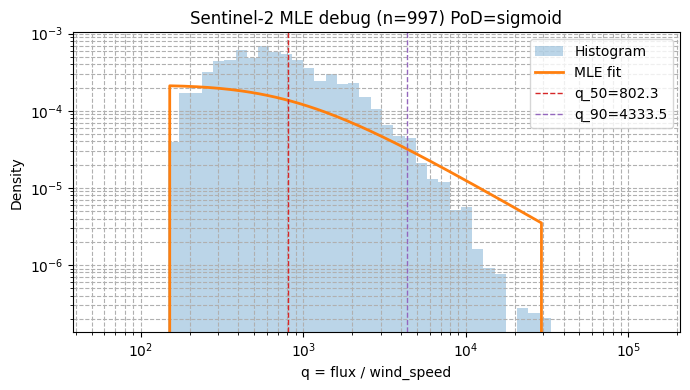

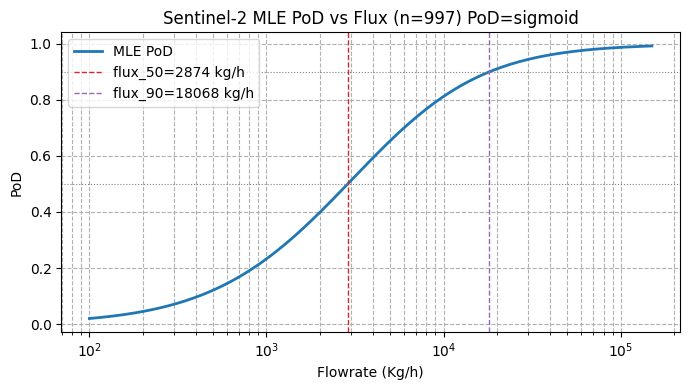

In [18]:
## Debug cell — MLE fit for Sentinel-2

pod_choice = PoDType.SIGMOID
fit_x_min = False
fit_x_max = False
x_max_fixed = 30_000
x_min_fixed = 150

subset_s2 = df_data[df_data["satellite_constellation"] == "Sentinel-2"]
subset_s2 = subset_s2[(subset_s2["ch4_fluxrate"] > 900) & (subset_s2["ch4_fluxrate"] < 50_000)]
q_s2 = (subset_s2["ch4_fluxrate"] / subset_s2["wind_speed"]).to_numpy()

print(f"Sentinel-2: n={len(q_s2)}")
print(f"q stats: min={q_s2.min():.2f}, median={np.median(q_s2):.2f}, "
      f"max={q_s2.max():.2f}, log(median)={np.log(np.median(q_s2)):.2f}, "
      f"std(log(q))={np.std(np.log(q_s2)):.2f}")

# Default guess and bounds
# Note: default_initial_guess now always returns 5 params [alpha, x_min, x_max, mu, sigma]
guess0_full = default_initial_guess(q_s2)
bounds0 = default_bounds(q_s2, fit_x_min=fit_x_min, fit_x_max=fit_x_max)
print(f"\nDefault initial guess [alpha, x_min, x_max, mu, sigma]: {guess0_full}")
print(f"Default bounds: alpha={bounds0.alpha}, mu={bounds0.mu}, sigma={bounds0.sigma}")
if fit_x_min:
    print(f"  x_min bounds: {bounds0.x_min}")
if fit_x_max:
    print(f"  x_max bounds: {bounds0.x_max}")

# q_50 and q_90 with the default initial guess
q50_guess = pod_quantile_from_params(0.5, guess0_full, pod=pod_choice)
q90_guess = pod_quantile_from_params(0.9, guess0_full, pod=pod_choice)
print(f"\n--- Default initial guess PoD quantiles (q-space) ---")
print(f"  q_50 = {q50_guess:.2f}   q_90 = {q90_guess:.2f}")
flux50_guess = pod_quantile_flux(0.5, guess0_full, wind_speeds, pod=pod_choice)
flux90_guess = pod_quantile_flux(0.9, guess0_full, wind_speeds, pod=pod_choice)
print(f"  flux_50 = {flux50_guess:.0f} Kg/h   flux_90 = {flux90_guess:.0f} Kg/h")

# Run MLE with defaults
# fit_mle will extract the appropriate subset of params to fit
mle_s2 = fit_mle(q_s2, pod=pod_choice, 
                 fit_x_min=fit_x_min, fit_x_max=fit_x_max,
                 x_max_fixed=x_max_fixed,
                 x_min_fixed=x_min_fixed,
                 bounds=bounds0)

print(f"\nMLE result: success={mle_s2.success}, msg={mle_s2.message}")
print(f"  params [alpha, x_min, x_max, mu, sigma]: {mle_s2.params}")
print(f"  -logL = {mle_s2.fun:.2f}")

# q_50 and q_90 after MLE fit
q50_mle = pod_quantile_from_params(0.5, mle_s2.params, pod=pod_choice)
q90_mle = pod_quantile_from_params(0.9, mle_s2.params, pod=pod_choice)
print(f"\n--- MLE fitted PoD quantiles (q-space) ---")
print(f"  q_50 = {q50_mle:.2f}   q_90 = {q90_mle:.2f}")
flux50_mle = pod_quantile_flux(0.5, mle_s2.params, wind_speeds, pod=pod_choice)
flux90_mle = pod_quantile_flux(0.9, mle_s2.params, wind_speeds, pod=pod_choice)
print(f"  flux_50 = {flux50_mle:.0f} Kg/h   flux_90 = {flux90_mle:.0f} Kg/h")

# ---- Plot density fit ----
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(q_s2, bins=bins, density=True, alpha=0.3, label="Histogram")
mle_pdf = pdf_on_grid(q_grid, mle_s2.params, pod=pod_choice)
ax.plot(q_grid, mle_pdf, color="C1", lw=2, label="MLE fit")
ax.axvline(q50_mle, color="C3", ls="--", lw=1, label=f"q_50={q50_mle:.1f}")
ax.axvline(q90_mle, color="C4", ls="--", lw=1, label=f"q_90={q90_mle:.1f}")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("q = flux / wind_speed"); ax.set_ylabel("Density")
ax.set_title(f"Sentinel-2 MLE debug (n={len(q_s2)}) PoD={pod_choice}")
ax.grid(True, which="both", ls="--"); ax.legend()
plt.tight_layout(); plt.show()

# ---- Plot PoD curve vs flux (marginalized over wind speeds) ----
fig, ax = plt.subplots(figsize=(7, 4))
pod_vals = pod_flux_on_grid(flux_grid, mle_s2.params, wind_speeds, pod=pod_choice)
ax.plot(flux_grid, pod_vals, color="C0", lw=2, label="MLE PoD")
ax.axhline(0.5, color="grey", ls=":", lw=0.8)
ax.axhline(0.9, color="grey", ls=":", lw=0.8)
ax.axvline(flux50_mle, color="C3", ls="--", lw=1, label=f"flux_50={flux50_mle:.0f} kg/h")
ax.axvline(flux90_mle, color="C4", ls="--", lw=1, label=f"flux_90={flux90_mle:.0f} kg/h")
ax.set_xscale("log")
ax.set_xlabel("Flowrate (Kg/h)"); ax.set_ylabel("PoD")
ax.set_title(f"Sentinel-2 MLE PoD vs Flux (n={len(q_s2)}) PoD={pod_choice}")
ax.grid(True, which="both", ls="--"); ax.legend()
plt.tight_layout(); plt.show()

# ---- Optionally try a manual initial guess ----
# Uncomment and tweak if the default doesn't converge:
# manual_guess = np.array([2.5, 1.0, 80000.0, 6.0, 1.0])  # Full 5 params: [alpha, x_min, x_max, mu, sigma]
# mle_s2_manual = fit_mle(q_s2, initial_guess=manual_guess, pod=pod_choice, 
#                         fit_x_min=False, fit_x_max=False)
# print(f"Manual MLE: success={mle_s2_manual.success}, params={mle_s2_manual.params}")


In [33]:
(subset_s2["ch4_fluxrate"] / subset_s2["wind_speed"]).describe()

count      1054.000000
mean       2044.031592
std        4900.890064
min          56.602452
25%         623.759931
50%        1196.612227
75%        2263.118240
max      140678.471218
dtype: float64

In [36]:
np.log(subset_s2["ch4_fluxrate"] / subset_s2["wind_speed"]).describe()

count    1054.000000
mean        7.105601
std         0.950843
min         4.036052
25%         6.435758
50%         7.087249
75%         7.724499
max        11.854232
dtype: float64

In [31]:
subset_s2["ch4_fluxrate"].describe()

count     1054.000000
mean      5423.736329
std       5438.459608
min        326.651044
25%       2116.037341
50%       3551.201002
75%       6847.026471
max      46167.861017
Name: ch4_fluxrate, dtype: float64

In [51]:
alpha, x_min, x_max, mu, sigma = guess0_full = default_initial_guess(q_s2)
norm_const = (alpha - 1.0) / (x_min_fixed ** (1.0 - alpha) - x_max_fixed ** (1.0 - alpha))
norm_const

150.64562410329984

In [53]:
alpha, x_min, x_max, mu, sigma

(2.0, 1.0, 6033.341689077011, 6.047894272226559, 0.2681619174623245)

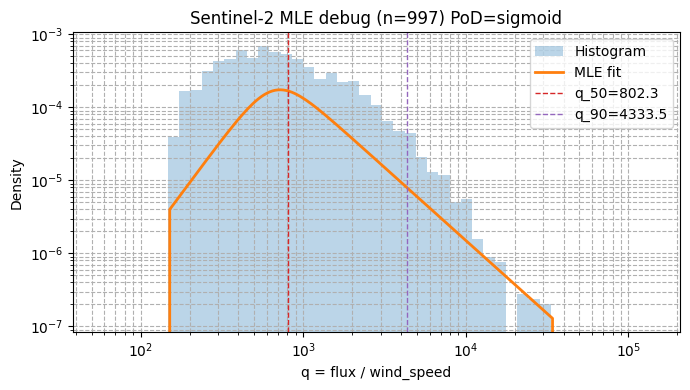

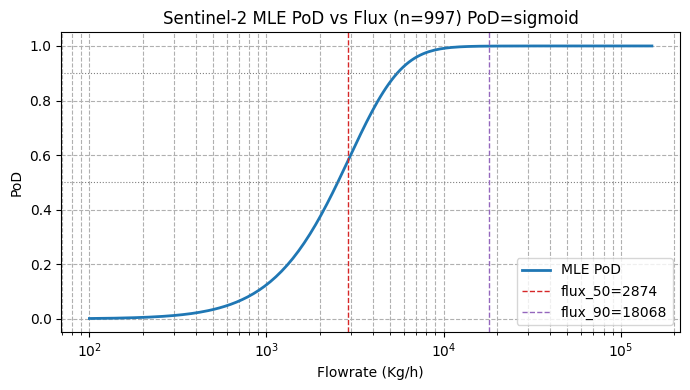

In [ ]:
# ---- Plot density fit ----
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(q_s2, bins=bins, density=True, alpha=0.3, label="Histogram")

alpha, x_min, x_max, mu, sigma = guess0_full = default_initial_guess(q_s2)
x_max_fixed = 35_000
x_min_fixed = 150
guess0_full[1] = x_min_fixed
guess0_full[2] = x_max_fixed

# mu
guess0_full[3] = 6.5

# sigma
guess0_full[4] = 0.2

# alpha
guess0_full[0] = 2

mle_pdf = pdf_on_grid(q_grid, guess0_full, pod=pod_choice)
ax.plot(q_grid, mle_pdf, color="C1", lw=2, label="MLE fit")
ax.axvline(q50_mle, color="C3", ls="--", lw=1, label=f"q_50={q50_mle:.1f}")
ax.axvline(q90_mle, color="C4", ls="--", lw=1, label=f"q_90={q90_mle:.1f}")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("q = flux / wind_speed"); ax.set_ylabel("Density")
ax.set_title(f"Sentinel-2 MLE debug (n={len(q_s2)}) PoD={pod_choice}")
ax.grid(True, which="both", ls="--"); ax.legend()
# ax.set_ylim(1e-8, 0.0005)
plt.tight_layout(); plt.show()

# ---- Plot PoD curve vs flux (marginalized over wind speeds) ----
fig, ax = plt.subplots(figsize=(7, 4))
pod_vals = pod_flux_on_grid(flux_grid, guess0_full, wind_speeds, pod=pod_choice)
ax.plot(flux_grid, pod_vals, color="C0", lw=2, label="MLE PoD")
ax.axhline(0.5, color="grey", ls=":", lw=0.8)
ax.axhline(0.9, color="grey", ls=":", lw=0.8)
ax.axvline(flux50_mle, color="C3", ls="--", lw=1, label=f"flux_50={flux50_mle:.0f}")
ax.axvline(flux90_mle, color="C4", ls="--", lw=1, label=f"flux_90={flux90_mle:.0f}")
ax.set_xscale("log")
ax.set_xlabel("Flowrate (Kg/h)"); ax.set_ylabel("PoD")
ax.set_title(f"Sentinel-2 MLE PoD vs Flux (n={len(q_s2)}) PoD={pod_choice}")
ax.grid(True, which="both", ls="--"); ax.legend()
plt.tight_layout(); plt.show()


In [34]:
x_min ** (1.0 - alpha) - x_max ** (1.0 - alpha)

0.9998342543731925

In [25]:
x_max

6033.341689077011

In [24]:
guess0_full

array([2.        , 1.        , 5.9174344 , 0.28511744])

Old model parameters converted to new parameterization:
  [alpha, x_min, mu, sigma] = [ 1.93037165  0.00787937 -4.67721885  0.32633261]
  alpha = 1.9304  (power-law exponent)
  x_min = 0.0079  (minimum flux)
  mu = -4.6772  (PoD midpoint in log-space)
  sigma = 0.3263  (PoD scale)

Old model PoD quantiles (q-space):
  q_50 = 0.01   q_90 = 0.02
  flux_50 = nan Kg/h   flux_90 = nan Kg/h


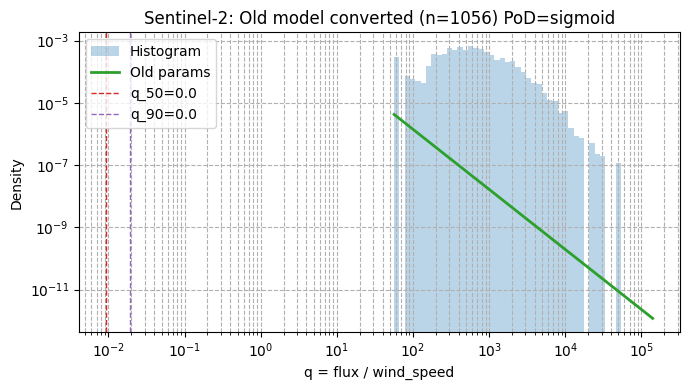

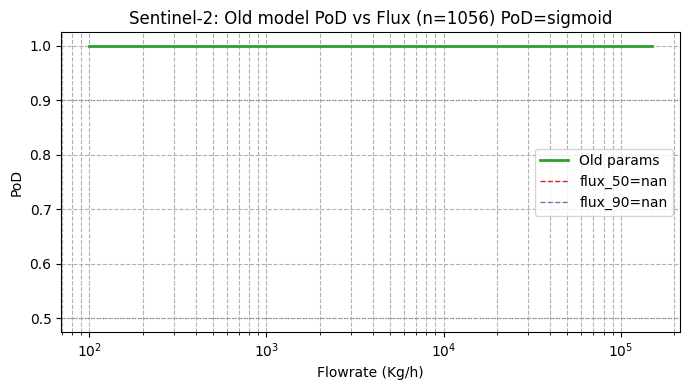

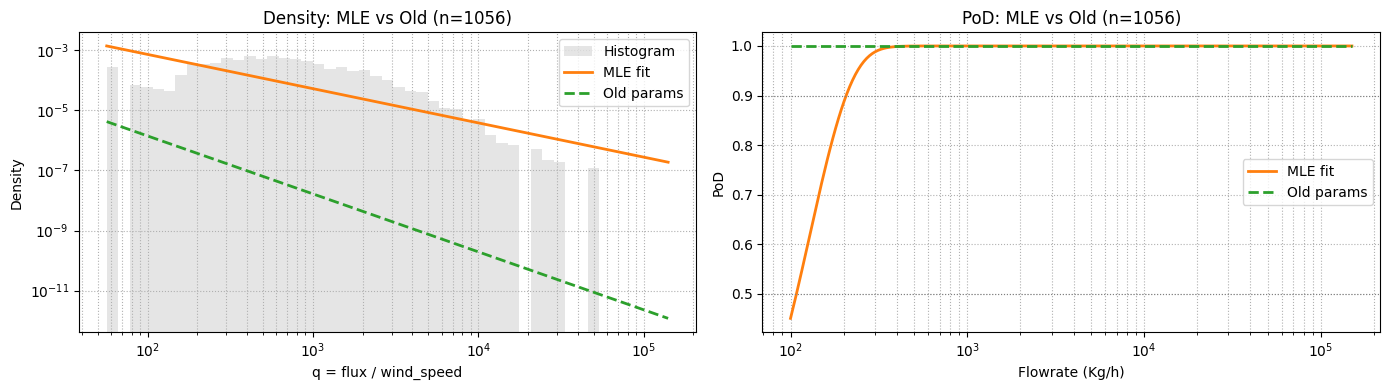

In [17]:
mle_s2.params

array([1.14061275, 1.        , 3.31896301, 0.05878027])

In [11]:
def fit_group(q_values: np.ndarray):
    """Fit the power-law x PoD model to wind-normalized flux rates q."""
    bounds = default_bounds(q_values)
    initial_guess = default_initial_guess(q_values)
    mle_fit = fit_mle(
        q_values,
        initial_guess=initial_guess,
        bounds=bounds,
        pod=pod_choice,
    )
    mcmc_fit = fit_mcmc(
        q_values,
        initial_guess=initial_guess,
        bounds=bounds,
        pod=pod_choice,
        **mcmc_config,
    )
    return mle_fit, mcmc_fit

Fitting satellite_constellation=Sentinel-2 (n=1056)


100%|██████████| 30000/30000 [24:54<00:00, 20.07it/s]


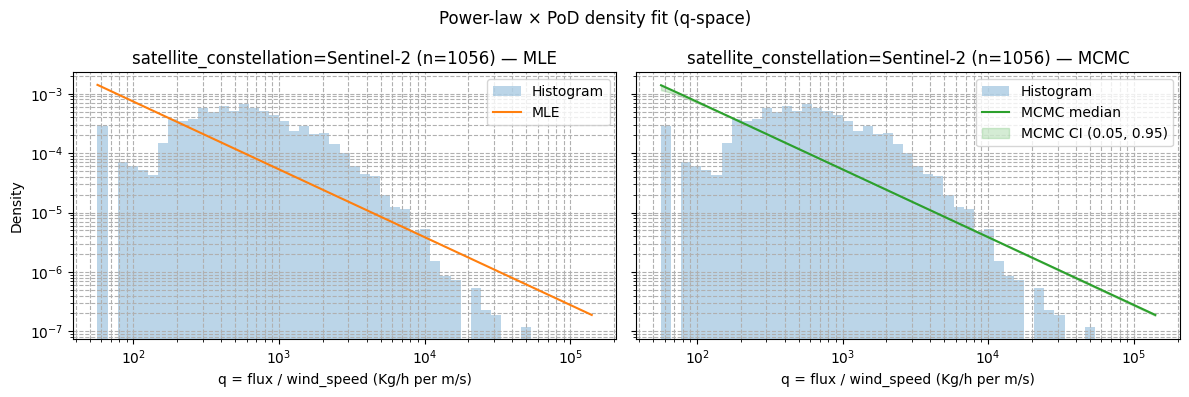

KeyboardInterrupt: 

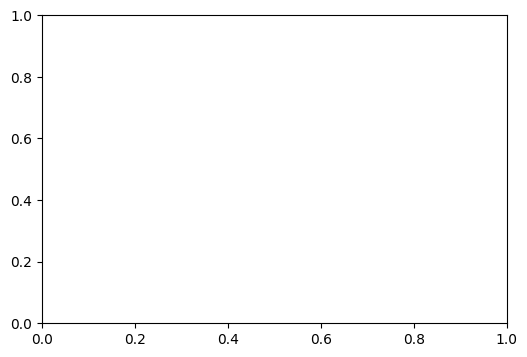

In [12]:
def run_group_fits(
    df: pd.DataFrame,
    group_col: str,
    group_values: list[str],
    bins: np.ndarray,
    q_grid: np.ndarray,
    flux_grid: np.ndarray,
    wind_speeds: np.ndarray,
    pod_choice: PoDType,
) -> None:
    for group in group_values:
        subset = df[df[group_col] == group]
        n = len(subset)
        if n < min_group_size:
            print(f"Skipping {group_col}={group} (n={n} < {min_group_size})")
            continue
        label = f"{group_col}={group} (n={n})"
        # Compute wind-normalized flux for this group
        q_values = (subset["ch4_fluxrate"] / subset["wind_speed"]).to_numpy()
        print(f"Fitting {label}")
        mle_fit, mcmc_fit = fit_group(q_values)
        # Density plot in q-space
        plot_density_comparison(
            q_values,
            mle_fit,
            mcmc_fit,
            label=label,
            bins=bins,
            q_grid=q_grid,
        )
        # PoD plot in flux-space (marginalized over wind speeds)
        plot_pod_curve(
            mcmc_fit,
            label=label,
            flux_grid=flux_grid,
            wind_speeds=wind_speeds,
        )


run_group_fits(
    df_data,
    group_col="satellite_constellation",
    group_values=constellation_groups,
    bins=bins,
    q_grid=q_grid,
    flux_grid=flux_grid,
    wind_speeds=wind_speeds,
    pod_choice=pod_choice,
)

run_group_fits(
    df_data,
    group_col="case_study",
    group_values=case_study_groups,
    bins=bins,
    q_grid=q_grid,
    flux_grid=flux_grid,
    wind_speeds=wind_speeds,
    pod_choice=pod_choice,
)